In [2]:
%matplotlib inline

import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.preprocessing import OneHotEncoder
from sklearn import preprocessing

import matplotlib.image as mpimg
from skimage.io import imread, imshow

#Import Tensorflow namespaces
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical


##### Tensorflow GPU ##########

#physical_devices = tf.config.experimental.list_physical_devices('GPU')
#tf.config.experimental.set_memory_growth(physical_devices[0], True)

In [3]:
# Import the dataset
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

In [4]:
# Split into features and targets

train_labels = df_train.label.values
test_labels = df_test.label.values

y_train = to_categorical(train_labels)
y_test = to_categorical(test_labels)

X_train = df_train.drop('label',axis=1).values
X_test  = df_test.drop('label',axis=1).values

print(y_train)


[[0. 1. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 ...
 [0. 0. 1. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]]


In [5]:
# Principle Component Analysis
number_of_components = 50
from sklearn.decomposition import PCA


pca_model = PCA(n_components=number_of_components, svd_solver='full')
pca_model.fit(X_train)


X_train_pca = pca_model.transform(X_train)
X_test_pca = pca_model.transform(X_test)

# Normalization

X_train_pca = X_train_pca / X_train_pca.max()
X_test_pca = X_test_pca / X_test_pca.max()


In [6]:
# Neural network initialization

activation = 'relu'
dropout_rate = 0.2
kernel_initializer ='uniform'
optimizer = 'adam'
lr = 0.01
batchsize = 32

model = Sequential()
model.add(Dense(50, input_dim=number_of_components, kernel_initializer=kernel_initializer,activation=activation))
model.add(Dropout(dropout_rate))
model.add(Dense(50, kernel_initializer=kernel_initializer,activation=activation))
model.add(Dropout(dropout_rate))
model.add(Dense(10,activation = 'softmax'))


model.compile(loss="categorical_crossentropy", optimizer=optimizer,metrics=['accuracy']) 

/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
history = model.fit(X_train_pca, y_train, epochs=10,validation_split=0.33, batch_size=batchsize,verbose=1)

Epoch 1/10
629/629 ━━━━━━━━━━━━━━━━━━━━ 1s 745us/step - accuracy: 0.5641 - loss: 1.6236 - val_accuracy: 0.8637 - val_loss: 0.4837
Epoch 2/10
629/629 ━━━━━━━━━━━━━━━━━━━━ 0s 629us/step - accuracy: 0.8265 - loss: 0.5588 - val_accuracy: 0.8850 - val_loss: 0.3848
Epoch 3/10
629/629 ━━━━━━━━━━━━━━━━━━━━ 0s 641us/step - accuracy: 0.8645 - loss: 0.4478 - val_accuracy: 0.9002 - val_loss: 0.3393
Epoch 4/10
629/629 ━━━━━━━━━━━━━━━━━━━━ 0s 662us/step - accuracy: 0.8773 - loss: 0.4055 - val_accuracy: 0.9063 - val_loss: 0.3073
Epoch 5/10
629/629 ━━━━━━━━━━━━━━━━━━━━ 0s 630us/step - accuracy: 0.8943 - loss: 0.3600 - val_accuracy: 0.9159 - val_loss: 0.2802
Epoch 6/10
629/629 ━━━━━━━━━━━━━━━━━━━━ 0s 648us/step - accuracy: 0.8994 - loss: 0.3327 - val_accuracy: 0.9226 - val_loss: 0.2613
Epoch 7/10
629/629 ━━━━━━━━━━━━━━━━━━━━ 0s 644us/step - accuracy: 0.9119 - loss: 0.3081 - val_accuracy: 0.9257 - val_loss: 0.2462
Epoch 8/10
629/629 ━━━━━━━━━━━━━━━━━━━━ 0s 626us/step - accuracy: 0.9170 - loss: 0.2736 - 

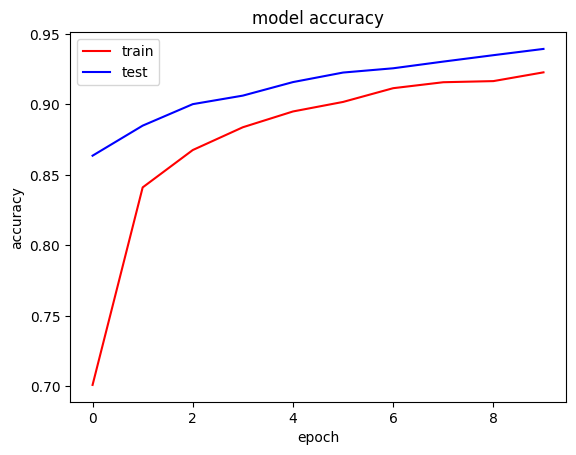

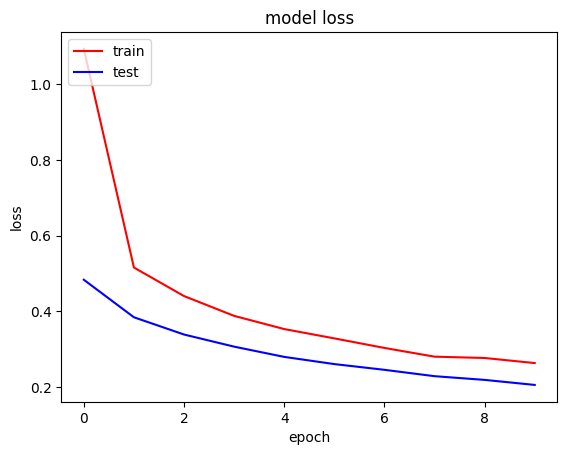

In [9]:
# Plot history

# Accuray 
plt.plot(history.history['accuracy'],'r')
plt.plot(history.history['val_accuracy'],'b')
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
# Loss 
plt.plot(history.history['loss'],'r')
plt.plot(history.history['val_loss'],'b')

plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [10]:
#y_predicted = model.predict_classes(X_test_pca,batch_size=1, verbose=1)
y_predicted = np.argmax(model.predict(X_test_pca),axis=-1)

375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 298us/step


In [11]:
print(y_predicted)

[3 8 0 ... 7 6 9]


In [12]:
print(y_predicted)
print(print(accuracy_score(test_labels, y_predicted)))

[3 8 0 ... 7 6 9]
0.9425833333333333
None


In [13]:
# Confusion matrix

print(classification_report(test_labels, y_predicted))

cf = confusion_matrix(test_labels, y_predicted)

print(cf)
print(accuracy_score(test_labels, y_predicted) * 100) 



              precision    recall  f1-score   support

           0       0.96      0.98      0.97      1195
           1       0.97      0.98      0.97      1352
           2       0.94      0.94      0.94      1157
           3       0.94      0.92      0.93      1258
           4       0.93      0.94      0.94      1140
           5       0.92      0.92      0.92      1076
           6       0.94      0.97      0.96      1167
           7       0.95      0.97      0.96      1268
           8       0.93      0.91      0.92      1174
           9       0.94      0.90      0.92      1213

    accuracy                           0.94     12000
   macro avg       0.94      0.94      0.94     12000
weighted avg       0.94      0.94      0.94     12000

[[1167    0    2    0    2    7   10    2    5    0]
 [   0 1324    2    5    1    2    2    5   10    1]
 [  10    2 1087    8   12    3   10   12   12    1]
 [   0    4   35 1154    0   30    4   11   14    6]
 [   0    3    3    0 1072   

# Grid search and hyperparameter tuning

In [14]:
def create_model(optimizer='adam', activation='relu', dropout_rate=0.0, kernel_initializer='uniform', neurons=10):
    """
    Creates and returns a Sequential neural network model.

    Parameters:
    - optimizer (str): The optimizer to use for training (default: 'adam').
    - activation (str): The activation function to use in the hidden layers (default: 'relu').
    - dropout_rate (float): The dropout rate to apply after each hidden layer (default: 0.0).
    - kernel_initializer (str): The initializer for the weights of the layers (default: 'uniform').
    - neurons (int): The number of neurons in each hidden layer (default: 10).

    Returns:
    - model (Sequential): The compiled Keras Sequential model.
    """
    # Initialize a Sequential model
    model = Sequential()

    # Input layer and first hidden layer
    # 'neurons' specifies the number of neurons in the layer
    # 'input_dim' specifies the number of input features (number_of_components)
    # 'kernel_initializer' initializes the weights
    # 'activation' specifies the activation function
    model.add(Dense(neurons, input_dim=number_of_components, kernel_initializer=kernel_initializer, activation=activation))

    # Apply dropout to reduce overfitting
    model.add(Dropout(dropout_rate))

    # Second hidden layer
    model.add(Dense(neurons, kernel_initializer=kernel_initializer, activation=activation))

    # Apply dropout again to reduce overfitting
    model.add(Dropout(dropout_rate))

    # Output layer
    # 10 neurons for 10 output classes (e.g., digits 0-9 in MNIST)
    # 'softmax' activation for multi-class classification
    model.add(Dense(10, activation='softmax'))

    # Compile the model
    # Loss function: Categorical cross-entropy for multi-class classification
    # Optimizer: Specified by the 'optimizer' parameter (default: 'adam')
    # Metrics: Accuracy to evaluate model performance
    model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

    # Return the compiled model
    return model

In [15]:
# Import KerasClassifier for wrapping the Keras model
from scikeras.wrappers import KerasClassifier

# Import GridSearchCV for hyperparameter tuning
from sklearn.model_selection import GridSearchCV

# Wrap the `create_model` function in a KerasClassifier
# This allows the model to be used with scikit-learn tools like GridSearchCV
model = KerasClassifier(build_fn=create_model, batch_size=batchsize, epochs=10)

# Define the hyperparameter grid for tuning
neurons = [5, 10, 20, 30, 40, 50]  # Number of neurons in the hidden layers
init = ['uniform', 'lecun_uniform', 'normal', 'zero', 'glorot_normal', 'glorot_uniform', 'he_normal', 'he_uniform']  # Weight initializers
optimizer = ['SGD', 'Adam']  # Optimizers to test
# Uncomment the following line to test additional optimizers
# optimizer = ['SGD', 'RMSprop', 'Adagrad', 'Adadelta', 'Adam', 'Adamax', 'Nadam']

epochs = [50]  # Number of epochs to test
batch_size = [16, 32]  # Batch sizes to test

# Create a dictionary of hyperparameters to test
param_grid = dict(epochs=epochs, batch_size=batch_size, optimizer=optimizer)

##############################################################
# Perform grid search to find the best hyperparameters
grid = GridSearchCV(estimator=model, param_grid=param_grid, verbose=3)

# Fit the grid search to the training data
# This will train the model for each combination of hyperparameters in `param_grid`
grid_result = grid.fit(X_train_pca, y_train)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Epoch 1/50


/opt/anaconda3/lib/python3.12/site-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 388us/step - accuracy: 0.3386 - loss: 1.8206
Epoch 2/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 386us/step - accuracy: 0.7590 - loss: 0.8019
Epoch 3/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 394us/step - accuracy: 0.8275 - loss: 0.5930
Epoch 4/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 372us/step - accuracy: 0.8455 - loss: 0.5309
Epoch 5/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 381us/step - accuracy: 0.8589 - loss: 0.4855
Epoch 6/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 379us/step - accuracy: 0.8693 - loss: 0.4490
Epoch 7/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 366us/step - accuracy: 0.8705 - loss: 0.4368
Epoch 8/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 393us/step - accuracy: 0.8776 - loss: 0.4138
Epoch 9/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 372us/step - accuracy: 0.8800 - loss: 0.4014
Epoch 10/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 374us/step - accuracy: 0.8854 - loss: 0.3941
Epoch 11/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 366us/step - accuracy: 0.8854 - loss: 0.3979
Epoch 12/50
1500/15

/opt/anaconda3/lib/python3.12/site-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 386us/step - accuracy: 0.4044 - loss: 1.8060
Epoch 2/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 396us/step - accuracy: 0.7976 - loss: 0.6764
Epoch 3/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 382us/step - accuracy: 0.8327 - loss: 0.5670
Epoch 4/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 400us/step - accuracy: 0.8545 - loss: 0.5094
Epoch 5/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 380us/step - accuracy: 0.8646 - loss: 0.4642
Epoch 6/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 371us/step - accuracy: 0.8758 - loss: 0.4302
Epoch 7/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 374us/step - accuracy: 0.8830 - loss: 0.4082
Epoch 8/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 368us/step - accuracy: 0.8860 - loss: 0.3886
Epoch 9/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 375us/step - accuracy: 0.8904 - loss: 0.3722
Epoch 10/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 389us/step - accuracy: 0.8955 - loss: 0.3617
Epoch 11/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 369us/step - accuracy: 0.9006 - loss: 0.3439
Epoch 12/50
1500/15

...

/opt/anaconda3/lib/python3.12/site-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 427us/step - accuracy: 0.3270 - loss: 1.8539
Epoch 2/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 391us/step - accuracy: 0.7448 - loss: 0.8035
Epoch 3/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 398us/step - accuracy: 0.8174 - loss: 0.6007
Epoch 4/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 389us/step - accuracy: 0.8375 - loss: 0.5514
Epoch 5/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 397us/step - accuracy: 0.8503 - loss: 0.5083
Epoch 6/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 406us/step - accuracy: 0.8584 - loss: 0.4769
Epoch 7/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 424us/step - accuracy: 0.8627 - loss: 0.4606
Epoch 8/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 420us/step - accuracy: 0.8678 - loss: 0.4437
Epoch 9/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 423us/step - accuracy: 0.8799 - loss: 0.4207
Epoch 10/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 402us/step - accuracy: 0.8781 - loss: 0.4123
Epoch 11/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 418us/step - accuracy: 0.8899 - loss: 0.3794
Epoch 12/50
1500/15

/opt/anaconda3/lib/python3.12/site-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 412us/step - accuracy: 0.3421 - loss: 1.8708
Epoch 2/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 396us/step - accuracy: 0.7329 - loss: 0.8214
Epoch 3/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 390us/step - accuracy: 0.7950 - loss: 0.6553
Epoch 4/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 384us/step - accuracy: 0.8245 - loss: 0.5739
Epoch 5/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 393us/step - accuracy: 0.8449 - loss: 0.5208
Epoch 6/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 387us/step - accuracy: 0.8569 - loss: 0.4898
Epoch 7/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 419us/step - accuracy: 0.8712 - loss: 0.4544
Epoch 8/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 388us/step - accuracy: 0.8771 - loss: 0.4242
Epoch 9/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 401us/step - accuracy: 0.8829 - loss: 0.4039
Epoch 10/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 423us/step - accuracy: 0.8931 - loss: 0.3780
Epoch 11/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 416us/step - accuracy: 0.8905 - loss: 0.3735
Epoch 12/50
1500/15

KeyboardInterrupt: 

In [16]:
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

Best: 0.920467 using {'batch_size': 16, 'epochs': 50, 'optimizer': 'Adam'}
0.920200 (0.005096) with: {'batch_size': 16, 'epochs': 50, 'optimizer': 'SGD'}
0.920467 (0.002821) with: {'batch_size': 16, 'epochs': 50, 'optimizer': 'Adam'}
0.917700 (0.004687) with: {'batch_size': 32, 'epochs': 50, 'optimizer': 'SGD'}
0.920333 (0.004062) with: {'batch_size': 32, 'epochs': 50, 'optimizer': 'Adam'}
